In [19]:
!pip install scikit-learn

In [35]:
import networkx as nx 

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte


In [21]:
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from sklearn.decomposition import PCA
import networkx as nx
from collections import defaultdict

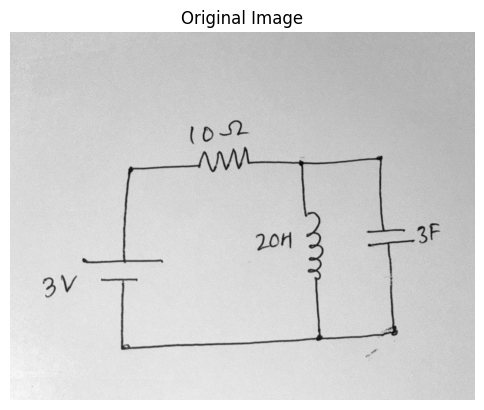

In [22]:
img_path = "/Users/mac/Downloads/LineDetect/ImageData/imgtotest.jpg"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found at {img_path}")

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


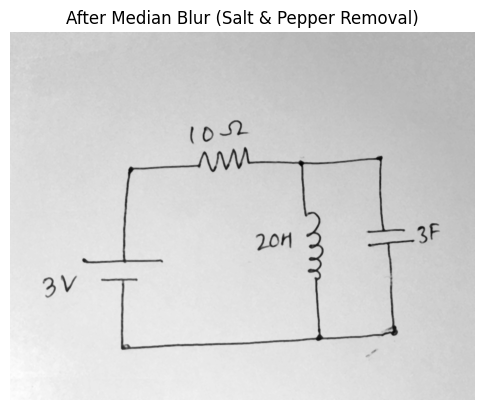

In [23]:
denoised = cv2.medianBlur(img, 5)

plt.figure(figsize=(6,6))
plt.imshow(denoised, cmap="gray")
plt.title("After Median Blur (Salt & Pepper Removal)")
plt.axis("off")
plt.show()


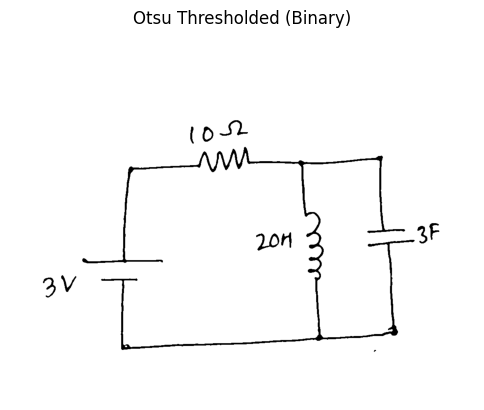

In [24]:
_, otsu_bin = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.imshow(otsu_bin, cmap="gray")
plt.title("Otsu Thresholded (Binary)")
plt.axis("off")
plt.show()


In [25]:
label_path = "/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt"
img = otsu_bin
h, w = img.shape

with open(label_path, "r") as f:
    yolo_lines = [ln.strip() for ln in f.readlines() if ln.strip()]



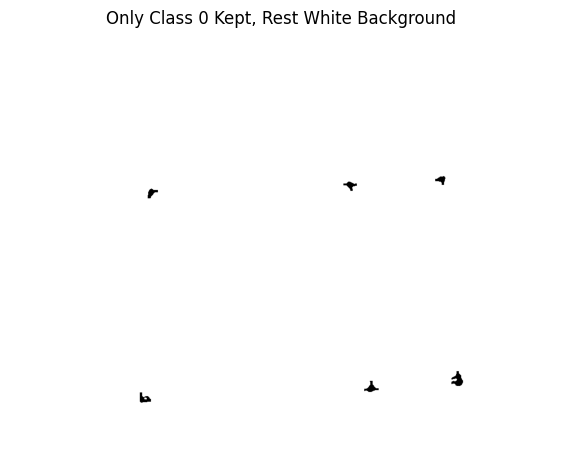

In [26]:
# --- Build mask from YOLO class 0 boxes ---
mask0 = np.zeros((h, w), dtype=np.uint8)

for ln in yolo_lines:
    parts = ln.split()
    if len(parts) < 5:
        continue
    if parts[0] != "1":
        continue

    # take only first 5 values (ignore confidence etc.)
    x, y, bw, bh = map(float, parts[1:5])

    x_center = int(x * w)
    y_center = int(y * h)
    box_w = int(bw * w)
    box_h = int(bh * h)

    x1 = max(0, x_center - box_w // 2)
    y1 = max(0, y_center - box_h // 2)
    x2 = min(w - 1, x_center + box_w // 2)
    y2 = min(h - 1, y_center + box_h // 2)

    cv2.rectangle(mask0, (x1, y1), (x2, y2), 255, thickness=-1)

# --- Keep only class 0 region, make rest white ---
result = np.full_like(img, 255)     # white background
result[mask0 == 255] = img[mask0 == 255]

plt.figure(figsize=(7,7))
plt.imshow(result, cmap="gray")
plt.title("Only Class 0 Kept, Rest White Background")
plt.axis("off")
plt.show()


Processing 14 lines from file...
Successfully removed 8 components. Kept Junctions.


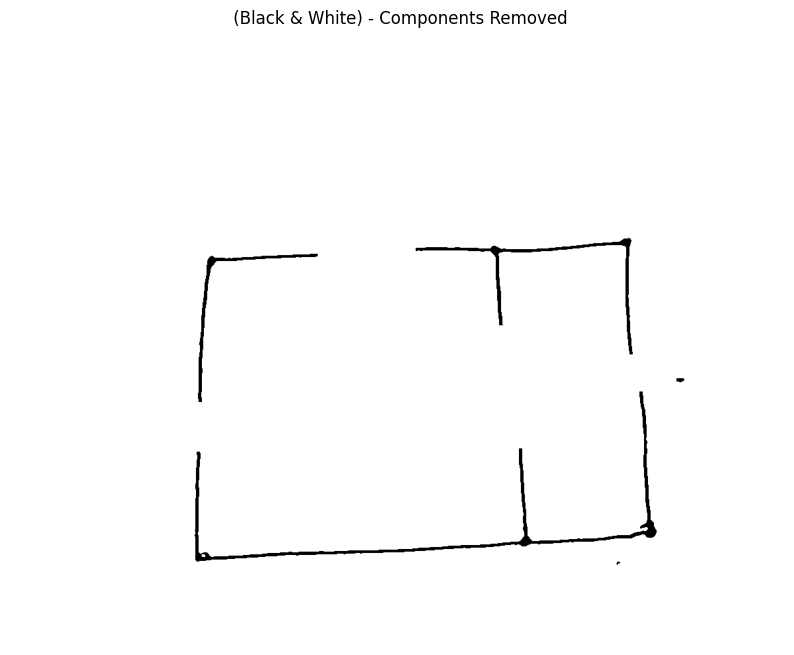

In [27]:
from matplotlib import image


def remove_components(image, label_path):
    # 1. FORCE GRAYSCALE (Black and White)
    # If the image has 3 channels (BGR/RGB), convert to 1 channel (Grayscale)
    cleaned_img = img
    
    # Get image dimensions
    img_h, img_w = cleaned_img.shape[:2]
    
    # 2. DEFINE ERASER FOR GRAYSCALE
    # For single channel images, Black is just 0 (scalar), not a tuple (0,0,0)
    ERASER_COLOR = 255
    
    try:
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        print(f"Processing {len(lines)} lines from file...")
        
        removed_count = 0
        
        for line in lines:
            parts = line.strip().split()
            if not parts: continue
            
            class_id = int(parts[0])
            
            # LOGIC: If it is NOT a junction (1), remove it
            if class_id != 1:
                # Parse normalized coordinates (0 to 1)
                x_center, y_center = float(parts[1]), float(parts[2])
                box_w, box_h = float(parts[3]), float(parts[4])
                
                # Convert to pixel coordinates
                x1 = int((x_center - box_w / 2) * img_w)
                y1 = int((y_center - box_h / 2) * img_h)
                x2 = int((x_center + box_w / 2) * img_w)
                y2 = int((y_center + box_h / 2) * img_h)
                
                # Clip coordinates
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_w, x2), min(img_h, y2)
                
                # Draw filled black rectangle
                cv2.rectangle(cleaned_img, (x1, y1), (x2, y2), ERASER_COLOR, thickness=-1)
                
                removed_count += 1
                
        print(f"Successfully removed {removed_count} components. Kept Junctions.")
        return cleaned_img

    except FileNotFoundError:
        print(f"Error: The file {label_path} was not found.")
        return image

# --- EXECUTION ---

txt_path = '/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt'

# Assumes 'img' is already loaded
if 'img' in locals():
    # Run the removal (Returns a Grayscale image)
    masked = remove_components(img, txt_path)

    # 3. Show Result in Black and White
    plt.figure(figsize=(10, 10))
    
    # 'cmap="gray"' ensures it interprets the values as Black/White
    # 'vmin=0, vmax=255' ensures strictly black (0) to white (255) contrast
    plt.imshow(masked, cmap='gray', vmin=0, vmax=255)
    
    plt.title(" (Black & White) - Components Removed")
    plt.axis('off')
    plt.show()
    
    # Save the result as a proper grayscale PNG
    # cv2.imwrite("clean_skeleton_bw.png", final_skeleton)

else:
    print("Please load 'skeleton_img' first.")

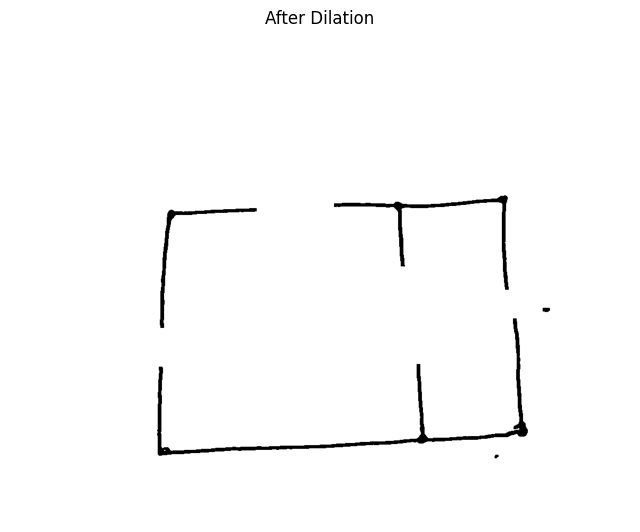

In [28]:
# invert so foreground becomes white for dilation
inv = cv2.bitwise_not(masked)

kernel = np.ones((3, 3), np.uint8)
dilated_inv = cv2.dilate(inv, kernel, iterations=1)

# invert back
dilated = cv2.bitwise_not(dilated_inv)

plt.figure(figsize=(8,8))
plt.imshow(dilated, cmap="gray", vmin=0, vmax=255)
plt.title("After Dilation")
plt.axis("off")
plt.show()


Foreground pixels: 16044
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


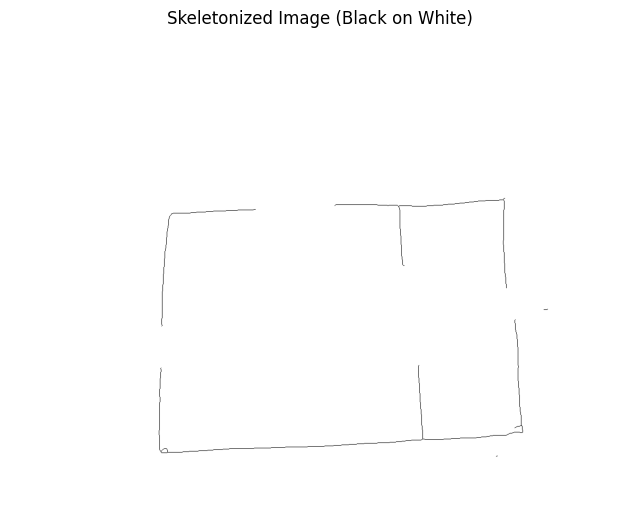

In [29]:
from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte

# Foreground = black pixels
binary = (dilated < 128).astype(np.uint8)   # 1 where black line exists

print("Foreground pixels:", np.sum(binary))

skel = skeletonize(binary).astype(np.uint8)
skel_u8 = img_as_ubyte(skel)

# Convert to black skeleton on white background for display
skel_black_on_white = np.ones_like(dilated) * 255
skel_black_on_white[skel_u8 > 0] = 0
print(skel)

plt.figure(figsize=(8,8))
plt.imshow(skel_black_on_white, cmap="gray", vmin=0, vmax=255)
plt.title("Skeletonized Image (Black on White)")
plt.axis("off")
plt.show()


In [30]:
# Convert skeleton to Hough input (white lines on black background)
hough_in = (skel_black_on_white < 128).astype(np.uint8) * 255


Found 5 connected components


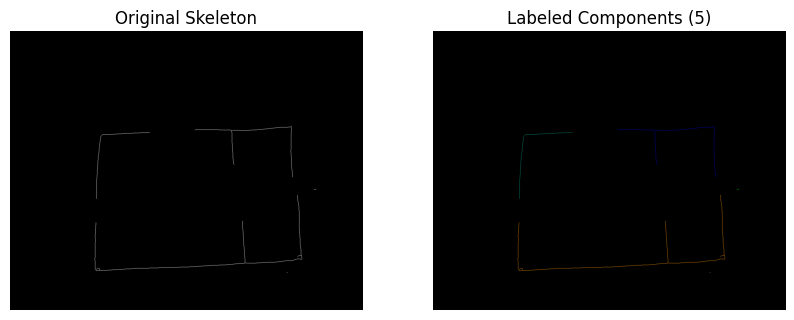

In [31]:
# Advanced Line Detection Pipeline
# Step 1: Label connected components
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from sklearn.decomposition import PCA
import networkx as nx
from collections import defaultdict

# Use the skeleton (binary format: 1 = foreground, 0 = background)
skeleton_binary = skel.astype(bool)

# Label connected components
labeled_components, num_components = label(skeleton_binary, connectivity=2, return_num=True)

print(f"Found {num_components} connected components")

# Visualize labeled components
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(skeleton_binary, cmap='gray')
plt.title("Original Skeleton")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(labeled_components, cmap='nipy_spectral')
plt.title(f"Labeled Components ({num_components})")
plt.axis('off')
plt.show()

Component 1: 4 endpoints, 4 junctions, 594 regular points
Component 2: 2 endpoints, 0 junctions, 369 regular points
Component 3: 2 endpoints, 0 junctions, 6 regular points
Component 4: 4 endpoints, 12 junctions, 1208 regular points
Component 5: 2 endpoints, 0 junctions, 1 regular points


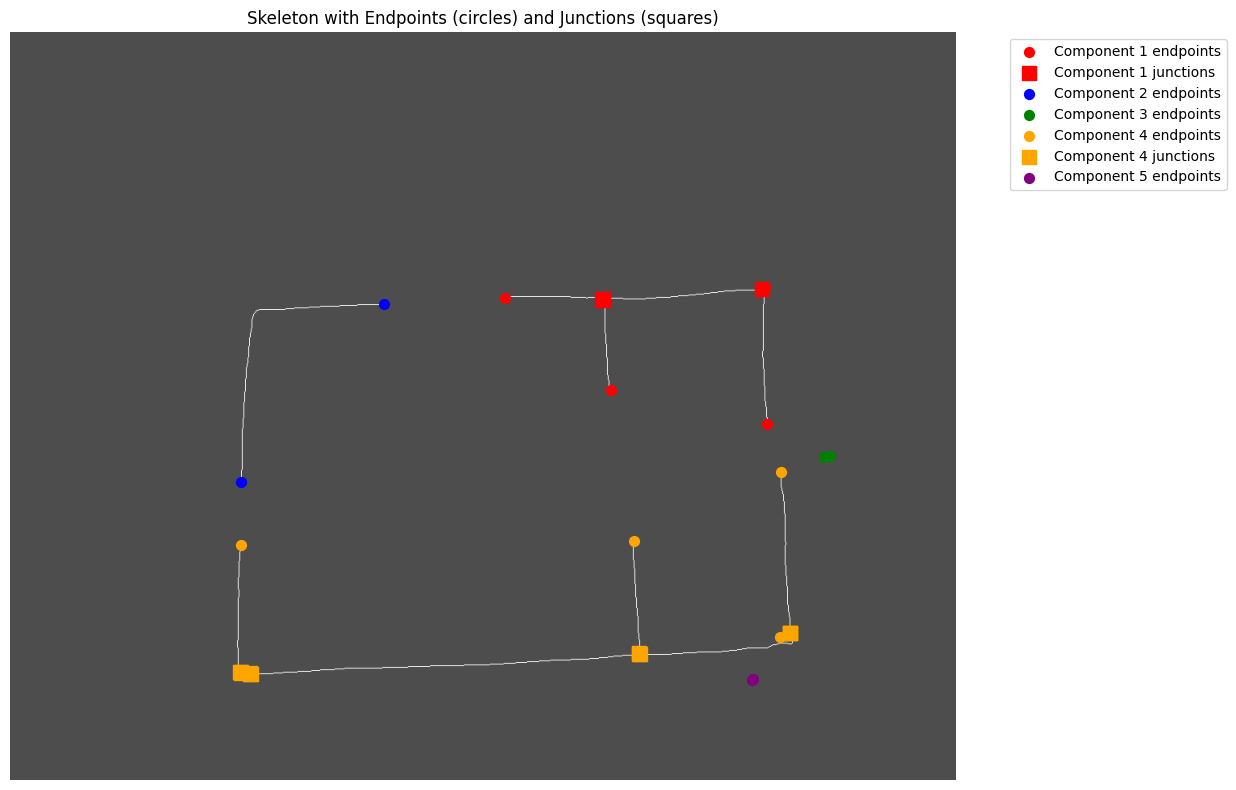

In [39]:
# Step 2: Find junctions and endpoints for each component
def get_pixel_degree(binary_image, y, x):
    """Calculate the degree (number of 8-neighbors) of a pixel"""
    if not binary_image[y, x]:
        return 0
    
    degree = 0
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dy == 0 and dx == 0:
                continue
            ny, nx_ = y + dy, x + dx
            if (0 <= ny < binary_image.shape[0] and 
                0 <= nx_ < binary_image.shape[1] and 
                binary_image[ny, nx_]):
                degree += 1
    return degree

def analyze_component_structure(component_mask):
    """Analyze a single connected component to find junctions and endpoints"""
    y_coords, x_coords = np.where(component_mask)
    
    endpoints = []
    junctions = []
    regular_points = []
    
    for y, x in zip(y_coords, x_coords):
        degree = get_pixel_degree(component_mask, y, x)
        if degree == 1:
            endpoints.append((y, x))
        elif degree >= 3:
            junctions.append((y, x))
        else:
            regular_points.append((y, x))
    
    return endpoints, junctions, regular_points

# Analyze all components
component_analysis = {}
for comp_id in range(1, num_components + 1):
    component_mask = (labeled_components == comp_id)
    endpoints, junctions, regular = analyze_component_structure(component_mask)
    component_analysis[comp_id] = {
        'endpoints': endpoints,
        'junctions': junctions,
        'regular_points': regular,
        'mask': component_mask
    }
    print(f"Component {comp_id}: {len(endpoints)} endpoints, {len(junctions)} junctions, {len(regular)} regular points")

# Visualize junctions and endpoints
plt.figure(figsize=(12, 8))
plt.imshow(skeleton_binary, cmap='gray', alpha=0.7)

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']
for i, (comp_id, analysis) in enumerate(component_analysis.items()):
    color = colors[i % len(colors)]
    
    # Plot endpoints
    if analysis['endpoints']:
        ep_y, ep_x = zip(*analysis['endpoints'])
        plt.scatter(ep_x, ep_y, c=color, marker='o', s=50, label=f'Component {comp_id} endpoints')
    
    # Plot junctions
    if analysis['junctions']:
        junc_y, junc_x = zip(*analysis['junctions'])
        plt.scatter(junc_x, junc_y, c=color, marker='s', s=100, label=f'Component {comp_id} junctions')

plt.title("Skeleton with Endpoints (circles) and Junctions (squares)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()

Extracted 61 paths from 5 components


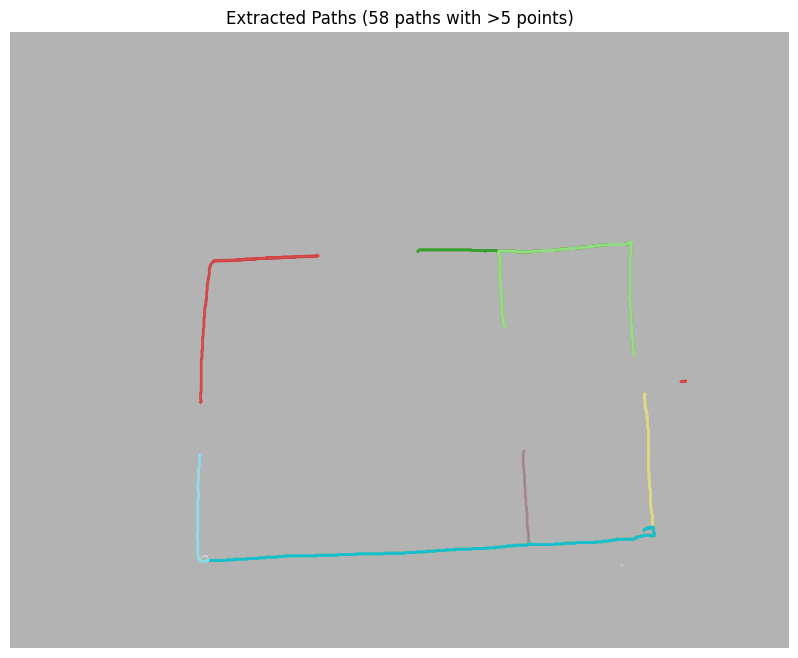

In [41]:
# Step 3: Split components into paths between junctions
import networkx as nx  # Ensure NetworkX is available in this cell

def find_paths_in_component(component_mask, endpoints, junctions):
    """Extract paths between junctions and endpoints in a component"""
    # Get all foreground pixels
    y_coords, x_coords = np.where(component_mask)
    pixels = [(y, x) for y, x in zip(y_coords, x_coords)]
    
    # If no junctions, the entire component is one path
    if not junctions:
        return [pixels]
    
    # Create a graph of the skeleton
    G = nx.Graph()
    for y, x in pixels:
        G.add_node((y, x))
        # Add edges to 8-connected neighbors
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                ny, nx_ = y + dy, x + dx
                if (0 <= ny < component_mask.shape[0] and 
                    0 <= nx_ < component_mask.shape[1] and 
                    component_mask[ny, nx_]):
                    G.add_edge((y, x), (ny, nx_))
    
    # Find paths between special points (junctions and endpoints)
    special_points = set(junctions + endpoints)
    paths = []
    
    for start_point in special_points:
        for end_point in special_points:
            if start_point != end_point:
                try:
                    path = nx.shortest_path(G, start_point, end_point)
                    # Only add if it's a new path (not reverse of existing)
                    reverse_path = path[::-1]
                    if path not in paths and reverse_path not in paths:
                        paths.append(path)
                except nx.NetworkXNoPath:
                    continue
    
    # Remove duplicate/subset paths
    unique_paths = []
    for path in paths:
        is_subset = False
        for existing_path in unique_paths:
            if set(path).issubset(set(existing_path)):
                is_subset = True
                break
        if not is_subset:
            unique_paths.append(path)
    
    return unique_paths if unique_paths else [pixels]

# Extract paths from all components
all_paths = []
for comp_id, analysis in component_analysis.items():
    component_paths = find_paths_in_component(
        analysis['mask'], 
        analysis['endpoints'], 
        analysis['junctions']
    )
    all_paths.extend(component_paths)

print(f"Extracted {len(all_paths)} paths from {num_components} components")

# Visualize paths
plt.figure(figsize=(12, 8))
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)

colors = plt.cm.tab20(np.linspace(0, 1, len(all_paths)))
for i, path in enumerate(all_paths):
    if len(path) > 5:  # Only show paths with enough points
        path_y, path_x = zip(*path)
        plt.plot(path_x, path_y, color=colors[i], linewidth=2, alpha=0.8, label=f'Path {i+1}')

plt.title(f"Extracted Paths ({len([p for p in all_paths if len(p) > 5])} paths with >5 points)")
plt.axis('off')
plt.show()

Successfully fitted 58 lines from 61 paths


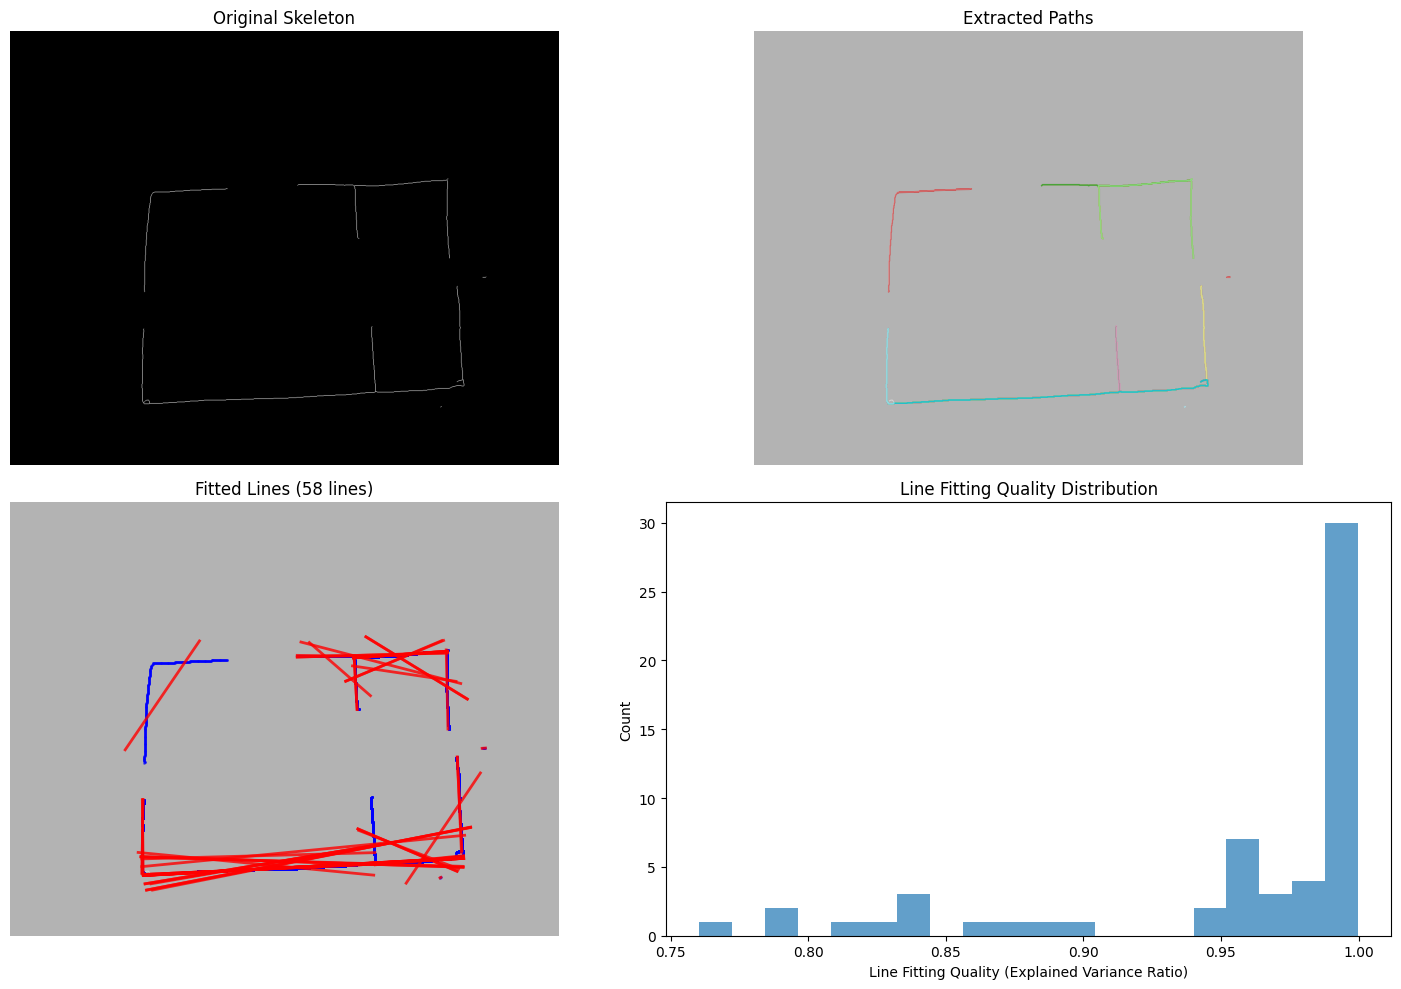

Line length statistics:
  Mean: 368.38 pixels
  Std:  231.53 pixels
  Min:  2.24 pixels
  Max:  704.88 pixels
Quality statistics:
  Mean: 0.955
  Min:  0.760
  Max:  1.000


In [42]:
# Step 4: Line fitting per path using PCA (Total Least Squares)
def fit_line_to_path(path_points, min_points=3):
    """Fit a line to a path using PCA and return line segment endpoints"""
    if len(path_points) < min_points:
        return None
    
    # Convert to numpy array
    points = np.array(path_points)
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Perform PCA
    pca = PCA(n_components=2)
    pca.fit(centered_points)
    
    # The first principal component gives us the line direction
    line_direction = pca.components_[0]
    
    # Project all points onto the line
    projections = np.dot(centered_points, line_direction)
    
    # Find the extent of the projections
    min_proj = np.min(projections)
    max_proj = np.max(projections)
    
    # Calculate the line segment endpoints
    start_point = centroid + min_proj * line_direction
    end_point = centroid + max_proj * line_direction
    
    # Calculate fitting quality (explained variance ratio)
    explained_variance_ratio = pca.explained_variance_ratio_[0]
    
    return {
        'start': start_point,
        'end': end_point,
        'direction': line_direction,
        'centroid': centroid,
        'length': max_proj - min_proj,
        'quality': explained_variance_ratio,
        'points': points
    }

# Fit lines to all paths
fitted_lines = []
for i, path in enumerate(all_paths):
    if len(path) > 2:  # Need at least 3 points for meaningful line fitting
        line_fit = fit_line_to_path(path)
        if line_fit and line_fit['quality'] > 0.7:  # Only keep good fits
            fitted_lines.append(line_fit)

print(f"Successfully fitted {len(fitted_lines)} lines from {len(all_paths)} paths")

# Visualize fitted lines
plt.figure(figsize=(15, 10))

# Plot original skeleton
plt.subplot(2, 2, 1)
plt.imshow(skeleton_binary, cmap='gray')
plt.title("Original Skeleton")
plt.axis('off')

# Plot paths
plt.subplot(2, 2, 2)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
colors = plt.cm.tab20(np.linspace(0, 1, len(all_paths)))
for i, path in enumerate(all_paths):
    if len(path) > 2:
        path_y, path_x = zip(*path)
        plt.plot(path_x, path_y, color=colors[i], linewidth=1, alpha=0.6)
plt.title("Extracted Paths")
plt.axis('off')

# Plot fitted lines
plt.subplot(2, 2, 3)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
for i, line in enumerate(fitted_lines):
    start_y, start_x = line['start']
    end_y, end_x = line['end']
    plt.plot([start_x, end_x], [start_y, end_y], 'r-', linewidth=2, alpha=0.8)
    
    # Plot original points for comparison
    points_y, points_x = line['points'][:, 0], line['points'][:, 1]
    plt.scatter(points_x, points_y, c='blue', s=1, alpha=0.5)

plt.title(f"Fitted Lines ({len(fitted_lines)} lines)")
plt.axis('off')

# Plot quality histogram
plt.subplot(2, 2, 4)
qualities = [line['quality'] for line in fitted_lines]
plt.hist(qualities, bins=20, alpha=0.7)
plt.xlabel('Line Fitting Quality (Explained Variance Ratio)')
plt.ylabel('Count')
plt.title('Line Fitting Quality Distribution')

plt.tight_layout()
plt.show()

# Print statistics
lengths = [line['length'] for line in fitted_lines]
print(f"Line length statistics:")
print(f"  Mean: {np.mean(lengths):.2f} pixels")
print(f"  Std:  {np.std(lengths):.2f} pixels")
print(f"  Min:  {np.min(lengths):.2f} pixels")
print(f"  Max:  {np.max(lengths):.2f} pixels")

print(f"Quality statistics:")
print(f"  Mean: {np.mean(qualities):.3f}")
print(f"  Min:  {np.min(qualities):.3f}")
print(f"  Max:  {np.max(qualities):.3f}")

Before merging: 58 lines
After merging: 27 lines


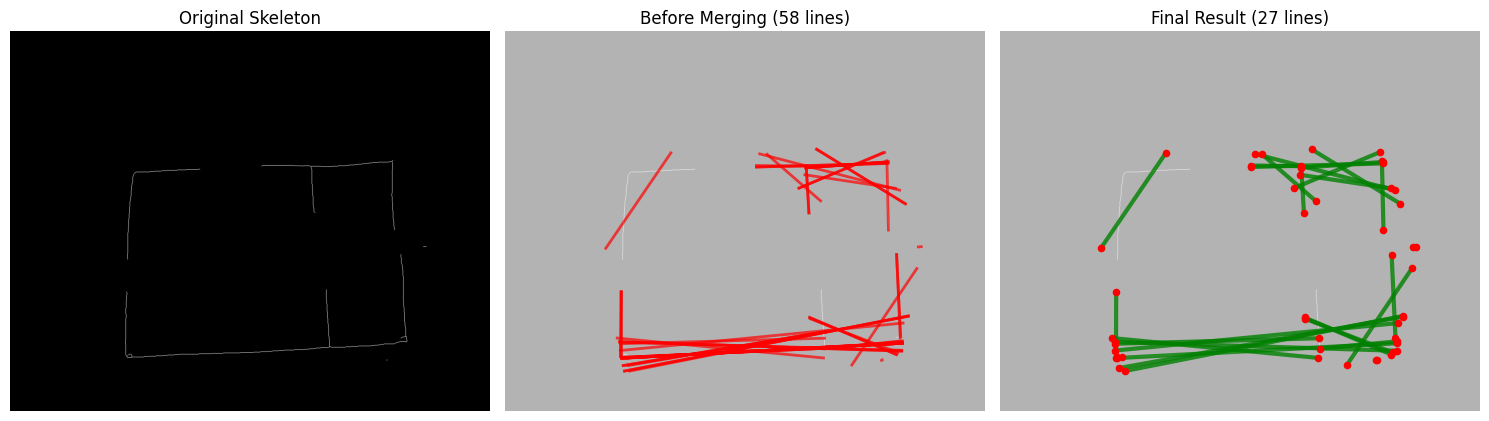

\n=== FINAL LINE DETECTION RESULTS ===
Line 1:
  Start: (613.0, 326.7)
  End:   (734.0, 328.2)
  Length: 121.0 pixels
  Quality: 1.000
  Angle: 0.7°

Line 2:
  Start: (733.1, 332.1)
  End:   (934.2, 317.8)
  Length: 201.6 pixels
  Quality: 1.000
  Angle: -4.1°

Line 3:
  Start: (734.5, 329.9)
  End:   (740.9, 442.2)
  Length: 112.4 pixels
  Quality: 1.000
  Angle: 86.7°

Line 4:
  Start: (759.5, 286.9)
  End:   (976.3, 420.0)
  Length: 254.4 pixels
  Quality: 0.796
  Angle: 31.5°

Line 5:
  Start: (613.0, 330.2)
  End:   (934.2, 321.5)
  Length: 321.3 pixels
  Quality: 0.999
  Angle: -1.6°

Line 6:
  Start: (638.9, 299.3)
  End:   (769.4, 412.8)
  Length: 173.0 pixels
  Quality: 0.828
  Angle: 41.0°

Line 7:
  Start: (621.0, 298.2)
  End:   (962.2, 386.7)
  Length: 352.5 pixels
  Quality: 0.896
  Angle: 14.5°

Line 8:
  Start: (716.6, 381.8)
  End:   (925.3, 294.3)
  Length: 226.3 pixels
  Quality: 0.881
  Angle: -22.7°

Line 9:
  Start: (731.1, 349.2)
  End:   (952.2, 382.2)
  Length:

In [43]:
# Step 5: Merge collinear neighbors
def angle_between_lines(line1, line2):
    """Calculate the angle between two line directions in degrees"""
    dir1 = line1['direction']
    dir2 = line2['direction']
    
    # Normalize directions (handle both orientations)
    if np.dot(dir1, dir2) < 0:
        dir2 = -dir2
    
    cos_angle = np.clip(np.dot(dir1, dir2), -1, 1)
    angle = np.arccos(cos_angle) * 180 / np.pi
    return min(angle, 180 - angle)  # Always return the acute angle

def distance_between_endpoints(line1, line2):
    """Calculate minimum distance between line endpoints"""
    points1 = [line1['start'], line1['end']]
    points2 = [line2['start'], line2['end']]
    
    min_dist = float('inf')
    for p1 in points1:
        for p2 in points2:
            dist = np.linalg.norm(p1 - p2)
            min_dist = min(min_dist, dist)
    
    return min_dist

def are_lines_collinear(line1, line2, angle_threshold=2.0, distance_threshold=10.0):
    """Check if two lines are approximately collinear"""
    # Check angle similarity
    angle_diff = angle_between_lines(line1, line2)
    if angle_diff > angle_threshold:
        return False
    
    # Check endpoint proximity
    endpoint_dist = distance_between_endpoints(line1, line2)
    if endpoint_dist > distance_threshold:
        return False
    
    return True

def merge_collinear_lines(lines, angle_threshold=2.0, distance_threshold=10.0):
    """Merge lines that are approximately collinear"""
    if not lines:
        return []
    
    merged_lines = []
    used = set()
    
    for i, line1 in enumerate(lines):
        if i in used:
            continue
        
        # Find all lines collinear with line1
        collinear_group = [line1]
        used.add(i)
        
        for j, line2 in enumerate(lines[i+1:], i+1):
            if j in used:
                continue
            
            if are_lines_collinear(line1, line2, angle_threshold, distance_threshold):
                collinear_group.append(line2)
                used.add(j)
        
        # Merge the collinear group into a single line
        if len(collinear_group) == 1:
            merged_lines.append(line1)
        else:
            # Collect all points from the group
            all_points = []
            for line in collinear_group:
                all_points.extend(line['points'].tolist())
            
            # Fit a new line to all combined points
            merged_line = fit_line_to_path(all_points)
            if merged_line:
                merged_lines.append(merged_line)
    
    return merged_lines

# Apply merging
print(f"Before merging: {len(fitted_lines)} lines")
merged_lines = merge_collinear_lines(fitted_lines, angle_threshold=2.0, distance_threshold=15.0)
print(f"After merging: {len(merged_lines)} lines")

# Visualize final result
plt.figure(figsize=(15, 5))

# Original skeleton
plt.subplot(1, 3, 1)
plt.imshow(skeleton_binary, cmap='gray')
plt.title("Original Skeleton")
plt.axis('off')

# Fitted lines (before merging)
plt.subplot(1, 3, 2)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
for line in fitted_lines:
    start_y, start_x = line['start']
    end_y, end_x = line['end']
    plt.plot([start_x, end_x], [start_y, end_y], 'r-', linewidth=2, alpha=0.7)
plt.title(f"Before Merging ({len(fitted_lines)} lines)")
plt.axis('off')

# Merged lines (final result)
plt.subplot(1, 3, 3)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
for line in merged_lines:
    start_y, start_x = line['start']
    end_y, end_x = line['end']
    plt.plot([start_x, end_x], [start_y, end_y], 'g-', linewidth=3, alpha=0.8)
    
    # Mark endpoints
    plt.scatter([start_x, end_x], [start_y, end_y], c='red', s=20, zorder=5)

plt.title(f"Final Result ({len(merged_lines)} lines)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Print final line information
print("\\n=== FINAL LINE DETECTION RESULTS ===")
for i, line in enumerate(merged_lines):
    start_y, start_x = line['start']
    end_y, end_x = line['end']
    length = line['length']
    quality = line['quality']
    
    print(f"Line {i+1}:")
    print(f"  Start: ({start_x:.1f}, {start_y:.1f})")
    print(f"  End:   ({end_x:.1f}, {end_y:.1f})")
    print(f"  Length: {length:.1f} pixels")
    print(f"  Quality: {quality:.3f}")
    
    # Calculate angle
    dx = end_x - start_x
    dy = end_y - start_y
    angle_deg = np.arctan2(dy, dx) * 180 / np.pi
    print(f"  Angle: {angle_deg:.1f}°")
    print()

In [44]:
# Comparison with Traditional Hough Transform
from skimage.transform import hough_line, hough_line_peaks

# Prepare image for traditional Hough transform
hough_input = (skeleton_binary * 255).astype(np.uint8)

# Apply Hough transform
tested_angles = np.linspace(-np.pi/2, np.pi/2, 360, endpoint=False)
h, angles, distances = hough_line(hough_input, theta=tested_angles)

# Find peaks
hough_peaks = hough_line_peaks(h, angles, distances, min_length=20, min_distance=10)

print(f"Traditional Hough Transform found {len(hough_peaks[0])} lines")

# Visualize comparison
plt.figure(figsize=(20, 5))

# Original image
plt.subplot(1, 4, 1)
plt.imshow(skeleton_binary, cmap='gray')
plt.title("Original Skeleton")
plt.axis('off')

# Traditional Hough Transform result
plt.subplot(1, 4, 2)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
for angle, dist in zip(hough_peaks[1], hough_peaks[2]):
    y0 = (dist - 0 * np.cos(angle)) / np.sin(angle) if np.sin(angle) != 0 else 0
    y1 = (dist - skeleton_binary.shape[1] * np.cos(angle)) / np.sin(angle) if np.sin(angle) != 0 else 0
    x0, x1 = 0, skeleton_binary.shape[1]
    
    if np.sin(angle) == 0:  # Vertical line
        x0 = x1 = dist / np.cos(angle)
        y0, y1 = 0, skeleton_binary.shape[0]
    
    plt.plot([x0, x1], [y0, y1], 'r-', linewidth=2, alpha=0.8)

plt.title(f"Traditional Hough ({len(hough_peaks[0])} lines)")
plt.axis('off')

# Our advanced method
plt.subplot(1, 4, 3)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
for line in merged_lines:
    start_y, start_x = line['start']
    end_y, end_x = line['end']
    plt.plot([start_x, end_x], [start_y, end_y], 'g-', linewidth=3, alpha=0.8)
    plt.scatter([start_x, end_x], [start_y, end_y], c='red', s=20)

plt.title(f"Advanced Method ({len(merged_lines)} lines)")
plt.axis('off')

# Side-by-side comparison
plt.subplot(1, 4, 4)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)

# Traditional Hough in red
for angle, dist in zip(hough_peaks[1], hough_peaks[2]):
    y0 = (dist - 0 * np.cos(angle)) / np.sin(angle) if np.sin(angle) != 0 else 0
    y1 = (dist - skeleton_binary.shape[1] * np.cos(angle)) / np.sin(angle) if np.sin(angle) != 0 else 0
    x0, x1 = 0, skeleton_binary.shape[1]
    
    if np.sin(angle) == 0:
        x0 = x1 = dist / np.cos(angle)
        y0, y1 = 0, skeleton_binary.shape[0]
    
    plt.plot([x0, x1], [y0, y1], 'r-', linewidth=1, alpha=0.6, label='Hough' if angle == hough_peaks[1][0] else "")

# Our method in green
for i, line in enumerate(merged_lines):
    start_y, start_x = line['start']
    end_y, end_x = line['end']
    plt.plot([start_x, end_x], [start_y, end_y], 'g-', linewidth=3, alpha=0.8, 
             label='Advanced' if i == 0 else "")

plt.title("Method Comparison")
plt.legend()
plt.axis('off')

plt.tight_layout()
plt.show()

print("\\n=== METHOD COMPARISON ===")
print(f"Traditional Hough Transform: {len(hough_peaks[0])} lines")
print(f"Advanced Component-Based Method: {len(merged_lines)} lines")
print("\\nAdvantages of the Advanced Method:")
print("- Respects component boundaries")
print("- Handles T-junctions properly") 
print("- Produces finite line segments (not infinite lines)")
print("- Better noise resistance")
print("- More accurate for hand-drawn/architectural drawings")

TypeError: hough_line_peaks() got an unexpected keyword argument 'min_length'

Detected lines: 22


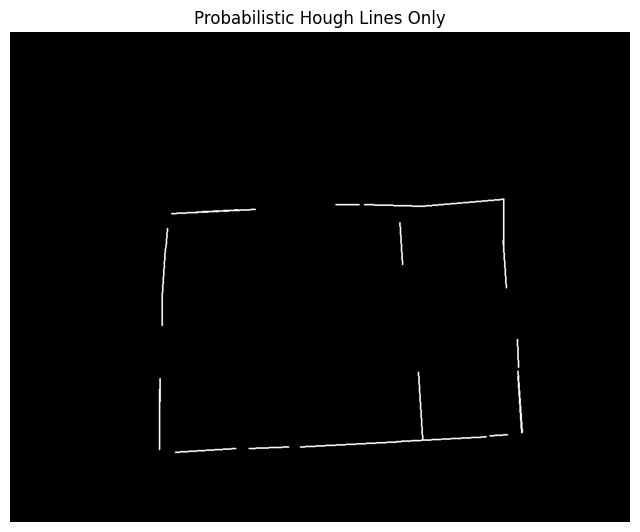

In [ ]:
blank = np.zeros((h, w), dtype=np.uint8)

lines = cv2.HoughLinesP(
    hough_in,
    rho=1,
    theta=np.pi / 180,
    threshold=20,        # low threshold for weak hand-drawn segments
    minLineLength=25,    # keep short segments too
    maxLineGap=25        # allow connecting broken strokes
)

# Draw lines on original image
vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

if lines is not None:
    print("Detected lines:", len(lines))
    for l in lines:
        x1, y1, x2, y2 = l[0]
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.line(blank, (x1, y1), (x2, y2), 255, 2)
else:
    print("No lines detected.")


plt.figure(figsize=(8,8))
plt.imshow(blank, cmap="gray", vmin=0, vmax=255)
plt.title("Probabilistic Hough Lines Only")
plt.axis("off")
plt.show()


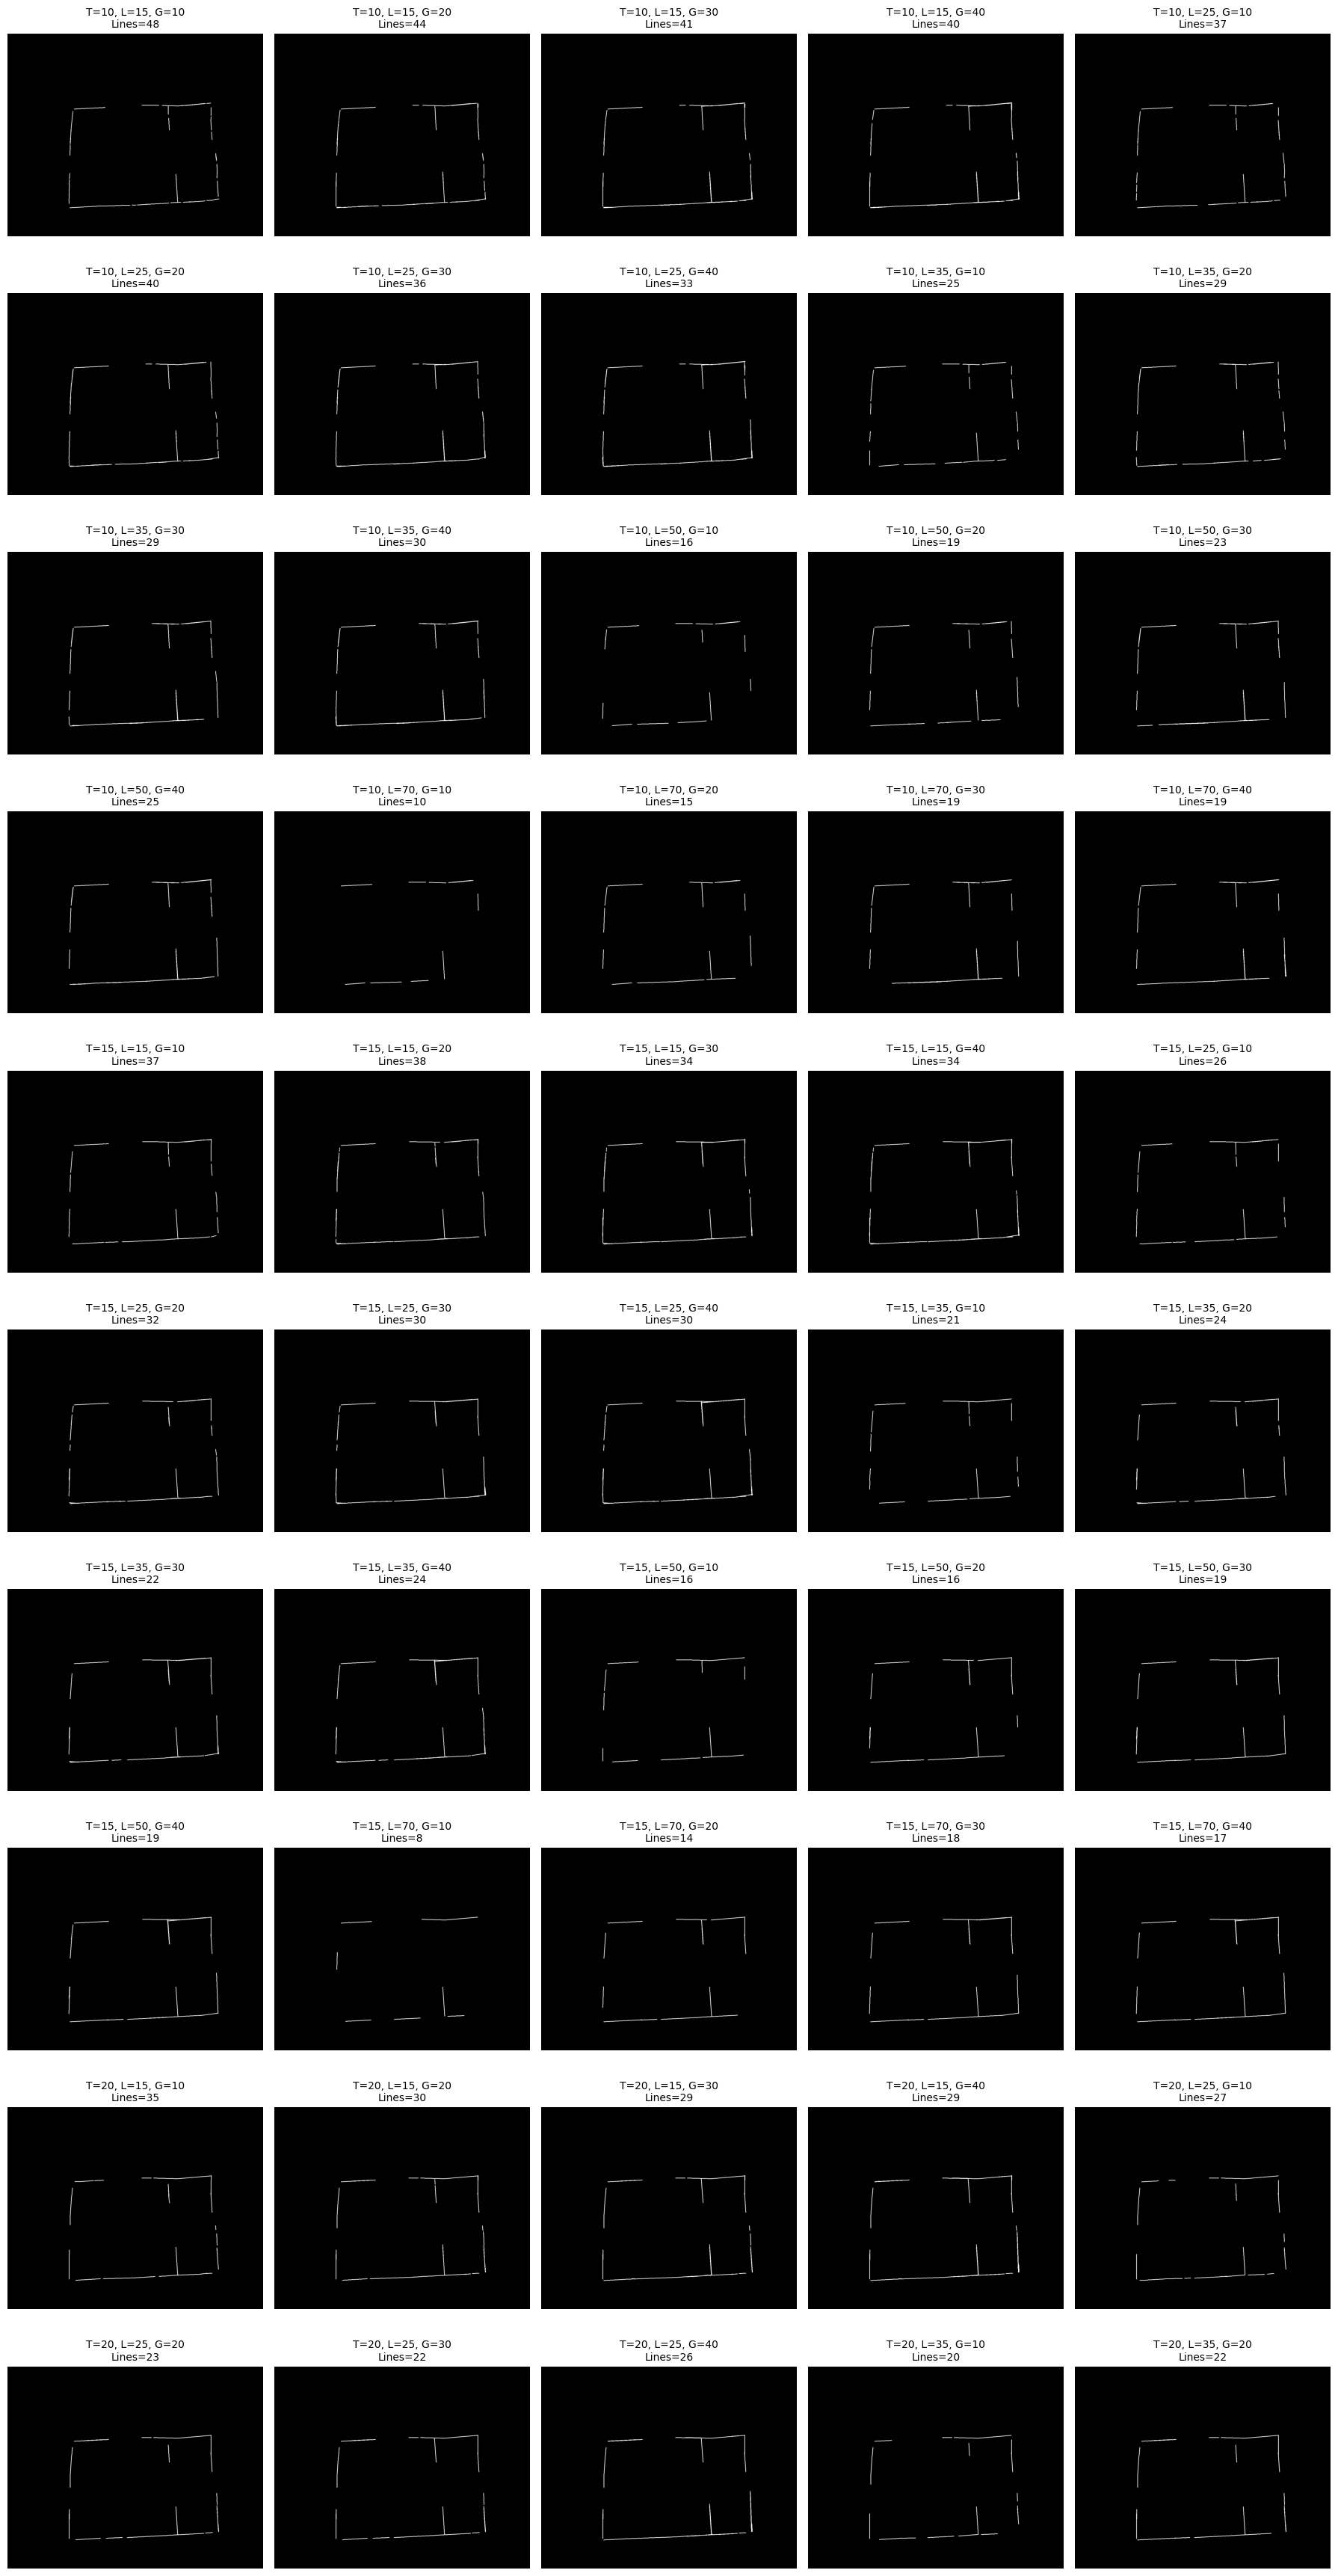

In [ ]:
import math

# --- Make sure this exists ---
# hough_in should be uint8 (0 or 255), white foreground on black background
# hough_in = (skel_black_on_white < 128).astype(np.uint8) * 255

# 50 hand-drawn friendly combinations
threshold_list      = [10, 15, 20, 25, 30, 35]          # sensitivity
minLineLength_list  = [15, 25, 35, 50, 70]          # allow short to medium segments
maxLineGap_list     = [10, 20,30,40]                      # connect broken stroke gaps

param_grid = []
for th in threshold_list:
    for mll in minLineLength_list:
        for mlg in maxLineGap_list:
            param_grid.append((th, mll, mlg))

param_grid = param_grid[:50]  # exactly 50

# subplot layout
cols = 5
rows = math.ceil(len(param_grid) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 3.5 * rows))
axes = axes.flatten()

for i, (th, mll, mlg) in enumerate(param_grid):
    lines = cv2.HoughLinesP(
        hough_in,
        rho=1,
        theta=np.pi / 180,
        threshold=th,
        minLineLength=mll,
        maxLineGap=mlg
    )

    # draw only detected lines on blank canvas
    canvas = np.zeros_like(hough_in)

    if lines is not None:
        for l in lines:
            x1, y1, x2, y2 = l[0]
            cv2.line(canvas, (x1, y1), (x2, y2), 255, 2)

        title = f"T={th}, L={mll}, G={mlg}\nLines={len(lines)}"
    else:
        title = f"T={th}, L={mll}, G={mlg}\nLines=0"

    axes[i].imshow(canvas, cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(title, fontsize=10)
    axes[i].axis("off")

# hide extra subplot cells if any
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Extracted 1 clean vector line segments


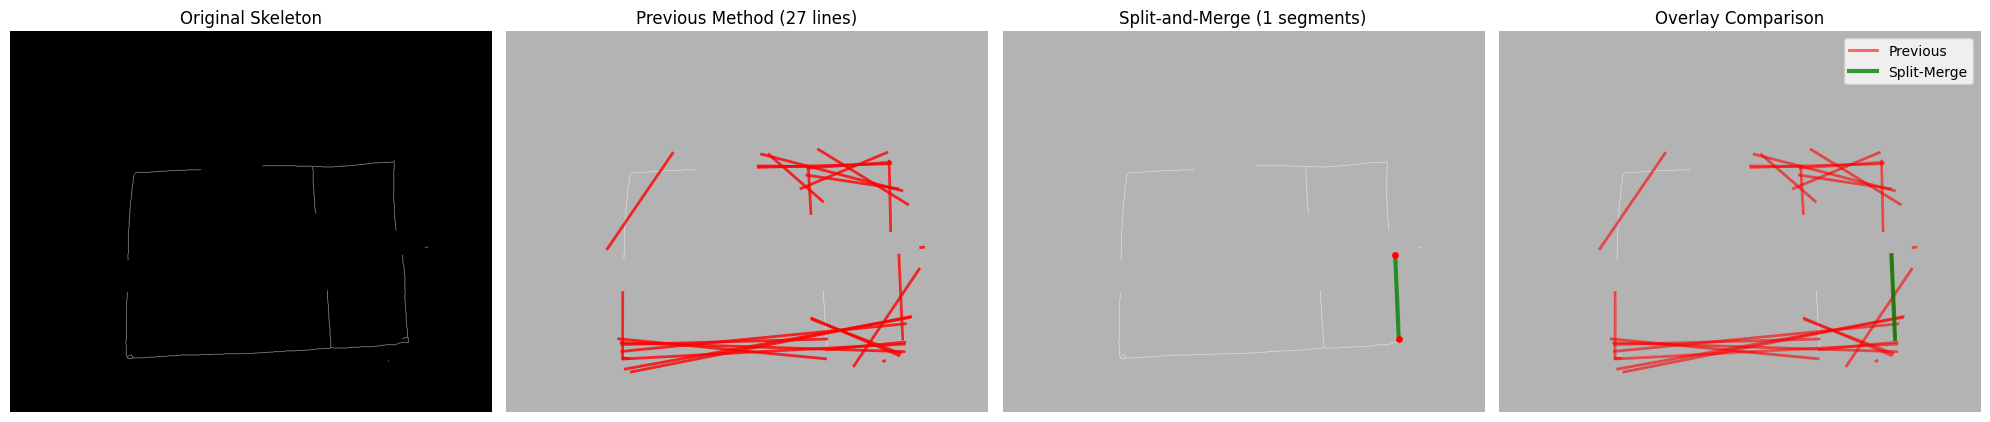


=== SPLIT-AND-MERGE VECTORIZATION RESULTS ===
Segment 1: (955.1,544.0) → (963.8,747.5), Length: 203.8px, Angle: 87.6°
SVG exported to vectorized_lines.svg


In [51]:
# Robust Line Vectorization with Split-and-Merge Segmentation
import xml.etree.ElementTree as ET

class LineVectorizer:
    def __init__(self, epsilon_px=1.5, min_points=10, min_len_px=20, 
                 angle_thresh_deg=2.0, gap_thresh_px=6, collinear_thresh_px=2.0):
        self.epsilon_px = epsilon_px
        self.min_points = min_points
        self.min_len_px = min_len_px
        self.angle_thresh_deg = angle_thresh_deg
        self.gap_thresh_px = gap_thresh_px
        self.collinear_thresh_px = collinear_thresh_px
        # self.direction_dot_min = 0.95  # add

    
    def fit_line_pca(self, points):
        """Fit line using PCA (Total Least Squares)"""
        if len(points) < 2:
            return None
        
        points = np.array(points)
        centroid = np.mean(points, axis=0)
        centered = points - centroid
        
        # PCA
        cov = np.cov(centered.T)
        eigenvals, eigenvecs = np.linalg.eigh(cov)
        
        # Direction is the eigenvector with larger eigenvalue
        direction = eigenvecs[:, np.argmax(eigenvals)]
        
        return centroid, direction
    
    def point_to_line_distance(self, points, line_center, line_direction):
        """Calculate perpendicular distance from points to line"""
        points = np.array(points)
        to_points = points - line_center
        
        # Project onto line direction
        projections = np.dot(to_points, line_direction)
        projected_points = line_center + projections[:, np.newaxis] * line_direction
        
        # Perpendicular distances
        distances = np.linalg.norm(points - projected_points, axis=1)
        return distances
    
    def split_and_merge_segment(self, path_points):
        """Recursively segment path using split-and-merge algorithm"""
        if len(path_points) < self.min_points:
            return []
        
        # Check if segment is long enough
        start_point = np.array(path_points[0])
        end_point = np.array(path_points[-1])
        segment_length = np.linalg.norm(end_point - start_point)
        
        if segment_length < self.min_len_px:
            return []
        
        # Fit line to full segment
        line_fit = self.fit_line_pca(path_points)
        if line_fit is None:
            return []
        
        line_center, line_direction = line_fit
        
        # Compute perpendicular distances
        distances = self.point_to_line_distance(path_points, line_center, line_direction)
        
        # Find maximum distance and its index
        max_dist_idx = np.argmax(distances)
        max_dist = distances[max_dist_idx]
        
        # If max distance is within tolerance, accept this segment
        if max_dist <= self.epsilon_px:
            return [path_points]
        
        # Otherwise, split at max distance point and recurse
        split_idx = max_dist_idx
        
        # Ensure we don't create too small segments
        if split_idx < self.min_points or (len(path_points) - split_idx) < self.min_points:
            return [path_points]  # Accept as is if split would create tiny segments
        
        left_segment = path_points[:split_idx + 1]  # Include split point in both
        right_segment = path_points[split_idx:]
        
        segments = []
        segments.extend(self.split_and_merge_segment(left_segment))
        segments.extend(self.split_and_merge_segment(right_segment))
        
        return segments
    
    def fit_segment_endpoints(self, segment_points):
        """Fit line to segment and return endpoints via projection"""
        if len(segment_points) < 2:
            return None
        
        line_fit = self.fit_line_pca(segment_points)
        if line_fit is None:
            return None
        
        line_center, line_direction = line_fit
        
        # Project all points onto the line
        points = np.array(segment_points)
        to_points = points - line_center
        projections = np.dot(to_points, line_direction)
        
        # Find min and max projections
        min_proj = np.min(projections)
        max_proj = np.max(projections)
        
        # Calculate endpoints
        start_point = line_center + min_proj * line_direction
        end_point = line_center + max_proj * line_direction
        
        return start_point[0], start_point[1], end_point[0], end_point[1]
    
    def segment_angle(self, x1, y1, x2, y2):
        """Calculate angle of line segment in degrees"""
        return np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
    
    def segments_angle_difference(self, seg1, seg2):
        """Calculate angle difference between two segments"""
        angle1 = self.segment_angle(*seg1)
        angle2 = self.segment_angle(*seg2)
        diff = abs(angle1 - angle2)
        return min(diff, 180 - diff)  # Always acute angle
    
    def endpoint_gap(self, seg1, seg2):
        """Calculate minimum gap between segment endpoints"""
        points1 = [(seg1[0], seg1[1]), (seg1[2], seg1[3])]
        points2 = [(seg2[0], seg2[1]), (seg2[2], seg2[3])]
        
        min_gap = float('inf')
        for p1 in points1:
            for p2 in points2:
                gap = np.linalg.norm(np.array(p1) - np.array(p2))
                min_gap = min(min_gap, gap)
        
        return min_gap
    
    def point_to_segment_distance(self, px, py, x1, y1, x2, y2):
        """Distance from point to line segment"""
        # Vector from start to end
        dx = x2 - x1
        dy = y2 - y1
        
        if dx == 0 and dy == 0:
            return np.sqrt((px - x1)**2 + (py - y1)**2)
        
        # Parameter t for projection onto line
        t = ((px - x1) * dx + (py - y1) * dy) / (dx * dx + dy * dy)
        t = max(0, min(1, t))  # Clamp to segment
        
        # Closest point on segment
        closest_x = x1 + t * dx
        closest_y = y1 + t * dy
        
        return np.sqrt((px - closest_x)**2 + (py - closest_y)**2)
    
    def are_segments_collinear(self, seg1, seg2):
        """Check if two segments are collinear"""
        # Check angle difference
        if self.segments_angle_difference(seg1, seg2) > self.angle_thresh_deg:
            return False
        
        # Check endpoint gap
        if self.endpoint_gap(seg1, seg2) > self.gap_thresh_px:
            return False
        
        # Check collinearity by distance from endpoints to other line
        x1, y1, x2, y2 = seg1
        x3, y3, x4, y4 = seg2
        
        d1 = self.point_to_segment_distance(x1, y1, x3, y3, x4, y4)
        d2 = self.point_to_segment_distance(x2, y2, x3, y3, x4, y4)
        d3 = self.point_to_segment_distance(x3, y3, x1, y1, x2, y2)
        d4 = self.point_to_segment_distance(x4, y4, x1, y1, x2, y2)
        
        max_dist = max(d1, d2, d3, d4)
        return max_dist <= self.collinear_thresh_px
    
    def merge_collinear_segments(self, segments):
        """Merge collinear segments into longer ones"""
        if len(segments) <= 1:
            return segments
        
        merged = []
        used = set()
        
        for i, seg1 in enumerate(segments):
            if i in used:
                continue
            
            # Find all segments collinear with seg1
            collinear_group = [seg1]
            used.add(i)
            
            for j, seg2 in enumerate(segments):
                if j in used or j <= i:
                    continue
                
                if self.are_segments_collinear(seg1, seg2):
                    collinear_group.append(seg2)
                    used.add(j)
            
            # If group has multiple segments, merge them
            if len(collinear_group) == 1:
                merged.append(seg1)
            else:
                # Collect all points from collinear segments
                all_points = []
                for seg in collinear_group:
                    all_points.extend([(seg[0], seg[1]), (seg[2], seg[3])])
                
                # Remove duplicates while preserving order
                seen = set()
                unique_points = []
                for point in all_points:
                    if point not in seen:
                        seen.add(point)
                        unique_points.append(point)
                
                # Fit new line to all points
                merged_seg = self.fit_segment_endpoints(unique_points)
                if merged_seg:
                    merged.append(merged_seg)
        
        return merged
    
    def extract_paths_from_skeleton(self, binary_skeleton):
        """Extract ordered paths from binary skeleton image"""
        # Use the existing connected component analysis
        labeled_components, num_components = label(binary_skeleton, connectivity=2, return_num=True)
        
        paths = []
        for comp_id in range(1, num_components + 1):
            component_mask = (labeled_components == comp_id)
            y_coords, x_coords = np.where(component_mask)
            
            if len(x_coords) > 2:  # Only process meaningful components
                # Simple path extraction: order points by distance
                points = list(zip(x_coords, y_coords))
                
                # Start from an endpoint if possible
                start_point = points[0]
                ordered_path = [start_point]
                remaining = set(points[1:])
                
                current = start_point
                while remaining:
                    # Find closest remaining point
                    min_dist = float('inf')
                    closest = None
                    for point in remaining:
                        dist = np.linalg.norm(np.array(current) - np.array(point))
                        if dist < min_dist:
                            min_dist = dist
                            closest = point
                    
                    if closest and min_dist <= 2:  # Allow small gaps for 8-connectivity
                        ordered_path.append(closest)
                        remaining.remove(closest)
                        current = closest
                    else:
                        break
                
                paths.append(ordered_path)
        
        return paths
    
    def vectorize_skeleton(self, binary_skeleton=None, paths=None):
        """Main vectorization function"""
        if paths is None:
            if binary_skeleton is None:
                raise ValueError("Must provide either binary_skeleton or paths")
            paths = self.extract_paths_from_skeleton(binary_skeleton)
        
        all_segments = []
        
        for path in paths:
            if len(path) < self.min_points:
                continue
            
            # Split path into straight segments
            segments = self.split_and_merge_segment(path)
            
            # Fit line to each segment
            for segment in segments:
                fitted_seg = self.fit_segment_endpoints(segment)
                if fitted_seg:
                    all_segments.append(fitted_seg)
        
        # Merge collinear segments
        merged_segments = self.merge_collinear_segments(all_segments)
        
        return merged_segments
    
    def visualize_segments(self, image, segments, segment_color=(0, 255, 0), thickness=2):
        """Visualize segments overlaid on image"""
        if len(image.shape) == 2:
            vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        else:
            vis = image.copy()
        
        for x1, y1, x2, y2 in segments:
            cv2.line(vis, (int(x1), int(y1)), (int(x2), int(y2)), segment_color, thickness)
        
        return vis
    
    def export_svg(self, segments, width, height, filename="vectorized.svg"):
        """Export segments as SVG"""
        svg = ET.Element("svg", width=str(width), height=str(height), 
                        xmlns="http://www.w3.org/2000/svg")
        
        for x1, y1, x2, y2 in segments:
            line = ET.SubElement(svg, "line", 
                               x1=f"{x1:.2f}", y1=f"{y1:.2f}",
                               x2=f"{x2:.2f}", y2=f"{y2:.2f}",
                               stroke="black", attrib={"stroke-width": "1"})
        
        tree = ET.ElementTree(svg)
        tree.write(filename)
        print(f"SVG exported to {filename}")

# Test the vectorizer on our skeleton
vectorizer = LineVectorizer(
    epsilon_px=1.2,
    min_points=10,
    min_len_px=20,
    angle_thresh_deg=2.0,
    gap_thresh_px=6.0,
    collinear_thresh_px=1.5
)

# Vectorize the skeleton
vector_segments = vectorizer.vectorize_skeleton(binary_skeleton=skeleton_binary)

print(f"Extracted {len(vector_segments)} clean vector line segments")

# Visualize results
plt.figure(figsize=(20, 5))

# Original skeleton
plt.subplot(1, 4, 1)
plt.imshow(skeleton_binary, cmap='gray')
plt.title("Original Skeleton")
plt.axis('off')

# Our previous method (for comparison)
plt.subplot(1, 4, 2)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
if 'merged_lines' in locals():
    for line in merged_lines:
        start_y, start_x = line['start']
        end_y, end_x = line['end']
        plt.plot([start_x, end_x], [start_y, end_y], 'r-', linewidth=2, alpha=0.8)
plt.title(f"Previous Method ({len(merged_lines) if 'merged_lines' in locals() else 0} lines)")
plt.axis('off')

# Split-and-merge vectorization
plt.subplot(1, 4, 3)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
for x1, y1, x2, y2 in vector_segments:
    plt.plot([x1, x2], [y1, y2], 'g-', linewidth=3, alpha=0.8)
    # Mark endpoints
    plt.scatter([x1, x2], [y1, y2], c='red', s=15, zorder=5)
plt.title(f"Split-and-Merge ({len(vector_segments)} segments)")
plt.axis('off')

# Overlay comparison
plt.subplot(1, 4, 4)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)

# Previous method in red
if 'merged_lines' in locals():
    for i, line in enumerate(merged_lines):
        start_y, start_x = line['start']
        end_y, end_x = line['end']
        plt.plot([start_x, end_x], [start_y, end_y], 'r-', linewidth=2, alpha=0.6, 
                 label='Previous' if i == 0 else "")

# New method in green
for i, (x1, y1, x2, y2) in enumerate(vector_segments):
    plt.plot([x1, x2], [y1, y2], 'g-', linewidth=3, alpha=0.8, 
             label='Split-Merge' if i == 0 else "")

plt.title("Overlay Comparison")
plt.legend()
plt.axis('off')

plt.tight_layout()
plt.show()

# Print segment information
print("\n=== SPLIT-AND-MERGE VECTORIZATION RESULTS ===")
for i, (x1, y1, x2, y2) in enumerate(vector_segments[:10]):  # Show first 10
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    angle = np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
    print(f"Segment {i+1}: ({x1:.1f},{y1:.1f}) → ({x2:.1f},{y2:.1f}), Length: {length:.1f}px, Angle: {angle:.1f}°")

if len(vector_segments) > 10:
    print(f"... and {len(vector_segments) - 10} more segments")

# Export SVG
if len(vector_segments) > 0:
    h, w = skeleton_binary.shape
    vectorizer.export_svg(vector_segments, w, h, "vectorized_lines.svg")

In [ ]:
# changed code a little bit


def seg_dir_unit(self, seg):
    x1, y1, x2, y2 = seg
    v = np.array([x2 - x1, y2 - y1], dtype=float)
    n = np.linalg.norm(v) + 1e-12
    return v / n



class LineVectorizer:
    def __init__(self, epsilon_px=1.5, min_points=10, min_len_px=20, 
                 angle_thresh_deg=2.0, gap_thresh_px=6, collinear_thresh_px=2.0):
        self.epsilon_px = epsilon_px
        self.min_points = min_points
        self.min_len_px = min_len_px

        self.angle_thresh_deg = angle_thresh_deg
        self.gap_thresh_px = gap_thresh_px
        self.collinear_thresh_px = collinear_thresh_px
        self.direction_dot_min = 0.95  # add

    
    def fit_line_pca(self, points):
        """Fit line using PCA (Total Least Squares)"""
        if len(points) < 2:
            return None
        
        points = np.array(points)
        centroid = np.mean(points, axis=0)
        centered = points - centroid
        
        # PCA
        cov = np.cov(centered.T)
        eigenvals, eigenvecs = np.linalg.eigh(cov)
        
        # Direction is the eigenvector with larger eigenvalue
        direction = eigenvecs[:, np.argmax(eigenvals)]
        
        return centroid, direction
    
    def point_to_line_distance(self, points, line_center, line_direction):
        """Calculate perpendicular distance from points to line"""
        points = np.array(points)
        to_points = points - line_center
        
        # Project onto line direction
        projections = np.dot(to_points, line_direction)
        projected_points = line_center + projections[:, np.newaxis] * line_direction
        
        # Perpendicular distances
        distances = np.linalg.norm(points - projected_points, axis=1)
        return distances
    
    def split_and_merge_segment(self, path_points):
        """Recursively segment path using split-and-merge algorithm"""
        if len(path_points) < self.min_points:
            return []
        
        # Check if segment is long enough
        start_point = np.array(path_points[0])
        end_point = np.array(path_points[-1])
        segment_length = np.linalg.norm(end_point - start_point)
        
        if segment_length < self.min_len_px:
            return []
        
        # Fit line to full segment
        line_fit = self.fit_line_pca(path_points)
        if line_fit is None:
            return []
        
        line_center, line_direction = line_fit
        
        # Compute perpendicular distances
        distances = self.point_to_line_distance(path_points, line_center, line_direction)
        
        # Find maximum distance and its index
        max_dist_idx = np.argmax(distances)
        max_dist = distances[max_dist_idx]
        
        # If max distance is within tolerance, accept this segment
        if max_dist <= self.epsilon_px:
            return [path_points]
        
        # Otherwise, split at max distance point and recurse
        split_idx = max_dist_idx
        
        # Ensure we don't create too small segments
        if split_idx < self.min_points or (len(path_points) - split_idx) < self.min_points:
            return [path_points]  # Accept as is if split would create tiny segments
        
        left_segment = path_points[:split_idx + 1]  # Include split point in both
        right_segment = path_points[split_idx:]
        
        segments = []
        segments.extend(self.split_and_merge_segment(left_segment))
        segments.extend(self.split_and_merge_segment(right_segment))
        
        return segments
    
    def fit_segment_endpoints(self, segment_points):
        """Fit line to segment and return endpoints via projection"""
        if len(segment_points) < 2:
            return None
        
        line_fit = self.fit_line_pca(segment_points)
        if line_fit is None:
            return None
        
        line_center, line_direction = line_fit
        
        # Project all points onto the line
        points = np.array(segment_points)
        to_points = points - line_center
        projections = np.dot(to_points, line_direction)
        
        # Find min and max projections
        min_proj = np.min(projections)
        max_proj = np.max(projections)
        
        # Calculate endpoints
        start_point = line_center + min_proj * line_direction
        end_point = line_center + max_proj * line_direction
        
        return start_point[0], start_point[1], end_point[0], end_point[1]
    
    def segment_angle(self, x1, y1, x2, y2):
        """Calculate angle of line segment in degrees"""
        return np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
    
    def segments_angle_difference(self, seg1, seg2):
        """Calculate angle difference between two segments"""
        angle1 = self.segment_angle(*seg1)
        angle2 = self.segment_angle(*seg2)
        diff = abs(angle1 - angle2)
        return min(diff, 180 - diff)  # Always acute angle
    
    def endpoint_gap(self, seg1, seg2):
        """Calculate minimum gap between segment endpoints"""
        points1 = [(seg1[0], seg1[1]), (seg1[2], seg1[3])]
        points2 = [(seg2[0], seg2[1]), (seg2[2], seg2[3])]
        
        min_gap = float('inf')
        for p1 in points1:
            for p2 in points2:
                gap = np.linalg.norm(np.array(p1) - np.array(p2))
                min_gap = min(min_gap, gap)
        
        return min_gap
    

    def point_to_segment_distance(self, px, py, x1, y1, x2, y2):
        """Distance from point to line segment"""
        # Vector from start to end
        dx = x2 - x1
        dy = y2 - y1
        
        if dx == 0 and dy == 0:
            return np.sqrt((px - x1)**2 + (py - y1)**2)
        
        # Parameter t for projection onto line
        t = ((px - x1) * dx + (py - y1) * dy) / (dx * dx + dy * dy)
        t = max(0, min(1, t))  # Clamp to segment
        
        # Closest point on segment
        closest_x = x1 + t * dx
        closest_y = y1 + t * dy
        
        return np.sqrt((px - closest_x)**2 + (py - closest_y)**2)
    
    
    def are_segments_collinear(self, seg1, seg2):
    # 1) angle check
        if self.segments_angle_difference(seg1, seg2) > self.angle_thresh_deg:
            return False

        # 2) direction agreement (avoid opposite-direction merges)
        d1 = self.seg_dir_unit(seg1)
        d2 = self.seg_dir_unit(seg2)
        if np.dot(d1, d2) < self.direction_dot_min:
            return False

        # 3) strict endpoint-to-endpoint gap check (must be actually "touching-ish")
        x1, y1, x2, y2 = seg1
        x3, y3, x4, y4 = seg2

        P = np.array([[x1,y1],[x2,y2]])
        Q = np.array([[x3,y3],[x4,y4]])

        # find closest endpoint pairing
        dists = np.linalg.norm(P[:,None,:] - Q[None,:,:], axis=2)
        min_gap = dists.min()
        if min_gap > self.gap_thresh_px:
            return False

        # 4) collinearity: endpoints close to the OTHER segment's INFINITE line
        # (not clamped segment distance)
        dist_a1 = self.point_to_infinite_line_distance(x1, y1, x3, y3, x4, y4)
        dist_a2 = self.point_to_infinite_line_distance(x2, y2, x3, y3, x4, y4)
        dist_b1 = self.point_to_infinite_line_distance(x3, y3, x1, y1, x2, y2)
        dist_b2 = self.point_to_infinite_line_distance(x4, y4, x1, y1, x2, y2)

        if max(dist_a1, dist_a2, dist_b1, dist_b2) > self.collinear_thresh_px:
            return False

        return True

    def merge_collinear_segments(self, segments):
        if len(segments) <= 1:
            return segments

        remaining = segments[:]
        merged_out = []

        while remaining:
            base = remaining.pop(0)
            group = [base]

            changed = True
            while changed:
                changed = False
                new_remaining = []
                for seg in remaining:
                    # IMPORTANT: compare seg to *any* segment in the current group (not only base)
                    if any(self.are_segments_collinear(g, seg) for g in group):
                        group.append(seg)
                        changed = True
                    else:
                        new_remaining.append(seg)
                remaining = new_remaining

            if len(group) == 1:
                merged_out.append(group[0])
            else:
                # Refit once using all endpoints in the group
                pts = []
                for s in group:
                    pts.append((s[0], s[1]))
                    pts.append((s[2], s[3]))

                merged_seg = self.fit_segment_endpoints(pts)
                if merged_seg:
                    merged_out.append(merged_seg)

        return merged_out

    
    def extract_paths_from_skeleton(self, binary_skeleton):
        """Extract ordered paths from binary skeleton image"""
        # Use the existing connected component analysis
        labeled_components, num_components = label(binary_skeleton, connectivity=2, return_num=True)
        
        paths = []
        for comp_id in range(1, num_components + 1):
            component_mask = (labeled_components == comp_id)
            y_coords, x_coords = np.where(component_mask)
            
            if len(x_coords) > 2:  # Only process meaningful components
                # Simple path extraction: order points by distance
                points = list(zip(x_coords, y_coords))
                
                # Start from an endpoint if possible
                start_point = points[0]
                ordered_path = [start_point]
                remaining = set(points[1:])
                
                current = start_point
                while remaining:
                    # Find closest remaining point
                    min_dist = float('inf')
                    closest = None
                    for point in remaining:
                        dist = np.linalg.norm(np.array(current) - np.array(point))
                        if dist < min_dist:
                            min_dist = dist
                            closest = point
                    
                    if closest and min_dist <= 2:  # Allow small gaps for 8-connectivity
                        ordered_path.append(closest)
                        remaining.remove(closest)
                        current = closest
                    else:
                        break
                
                paths.append(ordered_path)
        
        return paths
    
    def vectorize_skeleton(self, binary_skeleton=None, paths=None):
        """Main vectorization function"""
        if paths is None:
            if binary_skeleton is None:
                raise ValueError("Must provide either binary_skeleton or paths")
            paths = self.extract_paths_from_skeleton(binary_skeleton)
        
        all_segments = []
        
        for path in paths:
            if len(path) < self.min_points:
                continue
            
            # Split path into straight segments
            segments = self.split_and_merge_segment(path)
            
            # Fit line to each segment
            for segment in segments:
                fitted_seg = self.fit_segment_endpoints(segment)
                if fitted_seg:
                    all_segments.append(fitted_seg)
        
        # Merge collinear segments
        merged_segments = self.merge_collinear_segments(all_segments)
        
        return merged_segments
    
    def visualize_segments(self, image, segments, segment_color=(0, 255, 0), thickness=2):
        """Visualize segments overlaid on image"""
        if len(image.shape) == 2:
            vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        else:
            vis = image.copy()
        
        for x1, y1, x2, y2 in segments:
            cv2.line(vis, (int(x1), int(y1)), (int(x2), int(y2)), segment_color, thickness)
        
        return vis
    
    def export_svg(self, segments, width, height, filename="vectorized.svg"):
        """Export segments as SVG"""
        svg = ET.Element("svg", width=str(width), height=str(height), 
                        xmlns="http://www.w3.org/2000/svg")
        
        for x1, y1, x2, y2 in segments:
            line = ET.SubElement(svg, "line", 
                               x1=f"{x1:.2f}", y1=f"{y1:.2f}",
                               x2=f"{x2:.2f}", y2=f"{y2:.2f}",
                               stroke="black", attrib={"stroke-width": "1"})
        
        tree = ET.ElementTree(svg)
        tree.write(filename)
        print(f"SVG exported to {filename}")

# Test the vectorizer on our skeleton
vectorizer = LineVectorizer(
    epsilon_px=1.2,
    min_points=10,
    min_len_px=20,
    angle_thresh_deg=2.0,
    gap_thresh_px=6.0,
    collinear_thresh_px=1.5
)

# Vectorize the skeleton
vector_segments = vectorizer.vectorize_skeleton(binary_skeleton=skeleton_binary)

print(f"Extracted {len(vector_segments)} clean vector line segments")

# Visualize results
plt.figure(figsize=(20, 5))

# Original skeleton
plt.subplot(1, 4, 1)
plt.imshow(skeleton_binary, cmap='gray')
plt.title("Original Skeleton")
plt.axis('off')

# Our previous method (for comparison)
plt.subplot(1, 4, 2)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
if 'merged_lines' in locals():
    for line in merged_lines:
        start_y, start_x = line['start']
        end_y, end_x = line['end']
        plt.plot([start_x, end_x], [start_y, end_y], 'r-', linewidth=2, alpha=0.8)
plt.title(f"Previous Method ({len(merged_lines) if 'merged_lines' in locals() else 0} lines)")
plt.axis('off')

# Split-and-merge vectorization
plt.subplot(1, 4, 3)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)
for x1, y1, x2, y2 in vector_segments:
    plt.plot([x1, x2], [y1, y2], 'g-', linewidth=3, alpha=0.8)
    # Mark endpoints
    plt.scatter([x1, x2], [y1, y2], c='red', s=15, zorder=5)
plt.title(f"Split-and-Merge ({len(vector_segments)} segments)")
plt.axis('off')

# Overlay comparison
plt.subplot(1, 4, 4)
plt.imshow(skeleton_binary, cmap='gray', alpha=0.3)

# Previous method in red
if 'merged_lines' in locals():
    for i, line in enumerate(merged_lines):
        start_y, start_x = line['start']
        end_y, end_x = line['end']
        plt.plot([start_x, end_x], [start_y, end_y], 'r-', linewidth=2, alpha=0.6, 
                 label='Previous' if i == 0 else "")

# New method in green
for i, (x1, y1, x2, y2) in enumerate(vector_segments):
    plt.plot([x1, x2], [y1, y2], 'g-', linewidth=3, alpha=0.8, 
             label='Split-Merge' if i == 0 else "")

plt.title("Overlay Comparison")
plt.legend()
plt.axis('off')

plt.tight_layout()
plt.show()

# Print segment information
print("\n=== SPLIT-AND-MERGE VECTORIZATION RESULTS ===")
for i, (x1, y1, x2, y2) in enumerate(vector_segments[:10]):  # Show first 10
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    angle = np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
    print(f"Segment {i+1}: ({x1:.1f},{y1:.1f}) → ({x2:.1f},{y2:.1f}), Length: {length:.1f}px, Angle: {angle:.1f}°")

if len(vector_segments) > 10:
    print(f"... and {len(vector_segments) - 10} more segments")

# Export SVG
if len(vector_segments) > 0:
    h, w = skeleton_binary.shape
    vectorizer.export_svg(vector_segments, w, h, "vectorized_lines.svg")